In [2]:
import matplotlib
matplotlib.use('qtagg')
%matplotlib inline
import matplotlib.pyplot as plt

In [3]:
import scipy.linalg as la
import scipy.stats as stats
import numpy as np

### Vector 

In [4]:
a = np.array([[1.,-2., 3.],
              [4., 5., 6.],
              [7., 1., 9.]])

b = np.array([1., 2., 3.])
x, y, z = la.solve(a, b)
print(f"{x:.5f}", f"{y:.5f}", f"{z:.5f}")

print(f"x  - 2y + 3z = {  x - 2*y + 3*z} = b[0] = {b[0]}, checks out!")
print(f"4x - 5y + 6z = {4*x + 5*y + 6*z} = b[1] = {b[1]}, checks out!")
print(f"7x -  y + 9z = {7*x +   y + 9*z} = b[2] = {b[2]}, checks out!")

0.00000 0.00000 0.33333
x  - 2y + 3z = 1.0 = b[0] = 1.0, checks out!
4x - 5y + 6z = 2.0 = b[1] = 2.0, checks out!
7x -  y + 9z = 3.0 = b[2] = 3.0, checks out!


In [5]:
# Eigenvalue problem for A

eigenvalues, eigenvectors = la.eig(a)
if np.array_equal(eigenvalues.imag, np.zeros(len(eigenvalues))):
    print(f"Eigenvalues: e1 = {eigenvalues[0].real}, e2 = {eigenvalues[1].real}, e3 = {eigenvalues[2].real}")
else:
    print(f"Eigenvalues: e1 = {eigenvalues[0]}, e2 = {eigenvalues[1]}, e3 = {eigenvalues[2]}")

v1 = eigenvectors[:,0]
v2 = eigenvectors[:,1]
v3 = eigenvectors[:,2]
print(f"Eigenvectors: \n v1 = \n{v1.reshape(-1, 1)}, \n v2 = \n{v2.reshape(-1, 1)}, \n v3 = \n{v3.reshape(-1, 1)}")


Eigenvalues: e1 = -1.1326177168822582, e2 = 10.672695236923092, e3 = 5.459922479959154
Eigenvectors: 
 v1 = 
[[-0.8215735 ]
 [-0.02150583]
 [ 0.56969684]], 
 v2 = 
[[0.05324273]
 [0.74309552]
 [0.66706391]], 
 v3 = 
[[ 0.25636602]
 [-0.93563185]
 [-0.24263037]]


In [6]:
det_a = la.det(a)

if det_a != 0:
    inv_a = la.inv(a)
else:
    print("ERROR, matrix is singular, inverse is not defined")
    inv_a = NaN

print(f"det(a) = {det_a} \n inv(a) = \n{inv_a}")

det(a) = -66.0 
 inv(a) = 
[[-0.59090909 -0.31818182  0.40909091]
 [-0.09090909  0.18181818 -0.09090909]
 [ 0.46969697  0.22727273 -0.1969697 ]]


### Random matrix 

In [7]:
a = np.array([[1.,-2., 3.],
              [4., 5., 6.],
              [7., 1., 9.]])

rng = np.random.default_rng(99)
print(rng)

b_random = rng.integers(low=0, high=10, size=(3,3))
x, y, z = la.solve(a, b_random)
print(f"Solutions:\nx = {x}\ny = {y}\nz = {z}\n")

print("Double check")
print(f"x  - 2y + 3z = {  x - 2*y + 3*z}, b[0] = {b_random[0]}, checks out!")
print(f"4x - 5y + 6z = {4*x + 5*y + 6*z}, b[1] = {b_random[1]}, checks out!")
print(f"7x -  y + 9z = {7*x +   y + 9*z}, b[2] = {b_random[2]}, checks out!")


print(f"\nNorm of a, order 1: {la.norm(a, 1)}")
print(f"Norm of a, order 2: {la.norm(a, 2)}")


Generator(PCG64)
Solutions:
x = [-3.22727273  0.40909091 -2.04545455]
y = [-0.72727273 -1.09090909 -0.54545455]
z = [3.59090909 0.8030303  2.65151515]

Double check
x  - 2y + 3z = [9. 5. 7.], b[0] = [9 5 7], checks out!
4x - 5y + 6z = [5. 1. 5.], b[1] = [5 1 5], checks out!
7x -  y + 9z = [9. 9. 9.], b[2] = [9 9 9], checks out!

Norm of a, order 1: 18.0
Norm of a, order 2: 14.173659390884978


###  Statistics

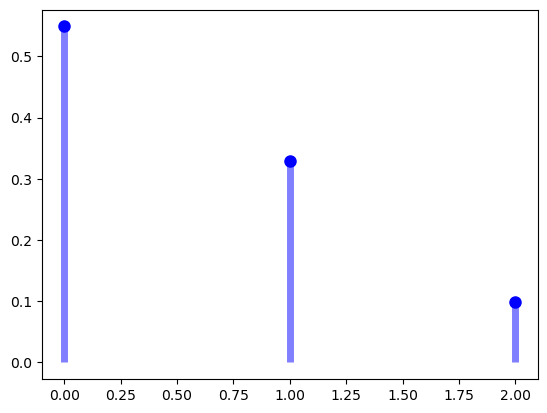

In [8]:
plt.close()
fig, ax = plt.subplots(1, 1)
mu = 0.6
lb, ub = stats.poisson.support(mu)

#first two moments of the distribution
mean, var = stats.poisson.stats(mu, moments='mv')

x = np.arange(stats.poisson.ppf(0.01, mu),
              stats.poisson.ppf(0.99, mu))
ax.plot(x, stats.poisson.pmf(x, mu), 'bo', ms=8, label='stats.poisson pmf')
ax.vlines(x, 0, stats.poisson.pmf(x, mu), colors='b', lw=5, alpha=0.5)
plt.show()


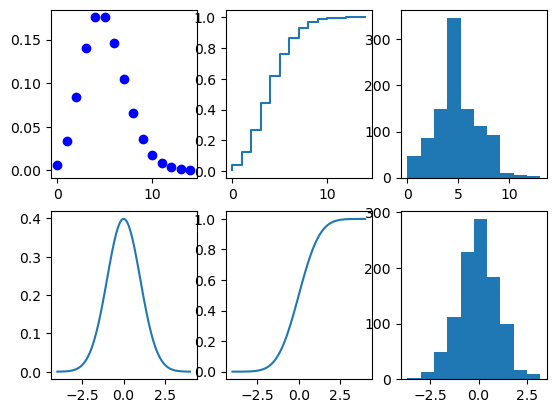

TtestResult(statistic=np.float64(1.608717619054097), pvalue=np.float64(0.10783608612205042), df=np.float64(1998.0))


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# tasks a, b, and c
fig, ax = plt.subplots(2, 3)

x1 = np.arange(15)
ax[0, 0].plot(x1, stats.poisson.pmf(x1, 5), 'bo')
ax[0, 1].step(x1, stats.poisson.cdf(x1, 5))
ax[0, 2].hist(stats.poisson.rvs(5, size=1000))

x2 = np.linspace(-4, 4, 100)
ax[1].set_title("b)")
ax[1, 0].plot(x2, stats.norm.pdf(x2))
ax[1, 1].plot(x2, stats.norm.cdf(x2))
ax[1, 2].hist(stats.norm.rvs(size=1000))

plt.show()
print(stats.ttest_ind(stats.norm.rvs(size=1000), stats.norm.rvs(size=1000)))